In [7]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


Упражнение 1.

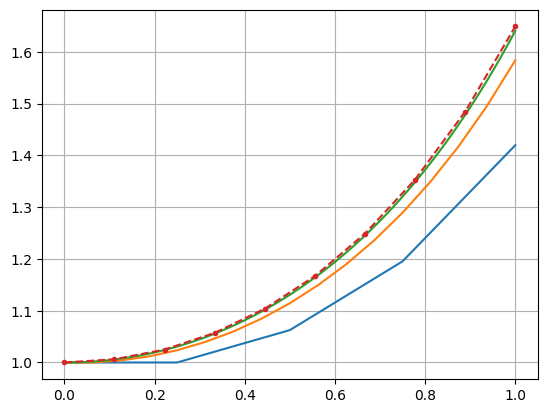

In [8]:
def compY(f, a, b, y0, n0):
    x = np.linspace(a, b, n0 + 1)
    y = [y0]
    for i in range(1, n0+1):
        yNew = y[i-1] + f(x[i-1], y[i-1])*(x[i] - x[i-1])
        y.append(yNew)
    return x, np.array(y)


def eulers(f, eps, a, b, x0, y0):
    diff = eps
    n0 = 2
    while eps <= diff:
        n0New = n0 * 2
        x, y = compY(f, a, b, y0, n0)
        xNew, yNew = compY(f, a, b, y0, n0New)
        diff = np.max(np.abs(y - yNew[::2]))
        n0 = n0New
    return xNew, yNew

x,y = sp.symbols('x, y')

dydx = lambda x, y: x*y

x0, y0 = 0, 1
eps = [1, 0.1, 0.01, 0.001]
a, b = 0, 1


for e in eps[:3:]:
  x, y = eulers(dydx, e, a, b, x0, y0)
  plt.plot(x, y, marker='o', linestyle='-', markersize = 0)


dxdyS = lambda x: np.exp(x**2/2)
x = np.linspace(a, b, 10)


plt.plot(x, dxdyS(x), marker='o', linestyle='--', markersize = 3)
plt.grid(True)
plt.show()

### Отчет по Упражнению 1 (Метод Эйлера)
В этом упражнении реализован метод Эйлера с адаптивным контролем шага для решения обыкновенного дифференциального уравнения (ОДУ) $dy/dx = x*y$ с начальным условием $y(0) = 1$. Функция `compY` выполняет один шаг вычисления методом Эйлера, а функция `eulers` итеративно уточняет размер шага ($n_0$), удваивая его до тех пор, пока разница между последовательными приближениями не станет меньше заданного допуска $\varepsilon$. Результаты показывают, что по мере уменьшения $\varepsilon$ (что означает требование более высокой точности), приближение становится ближе к точному решению $y = e^{x^2/2}$. Графики наглядно демонстрируют сходимость метода Эйлера к истинному решению.

Упражнение 2

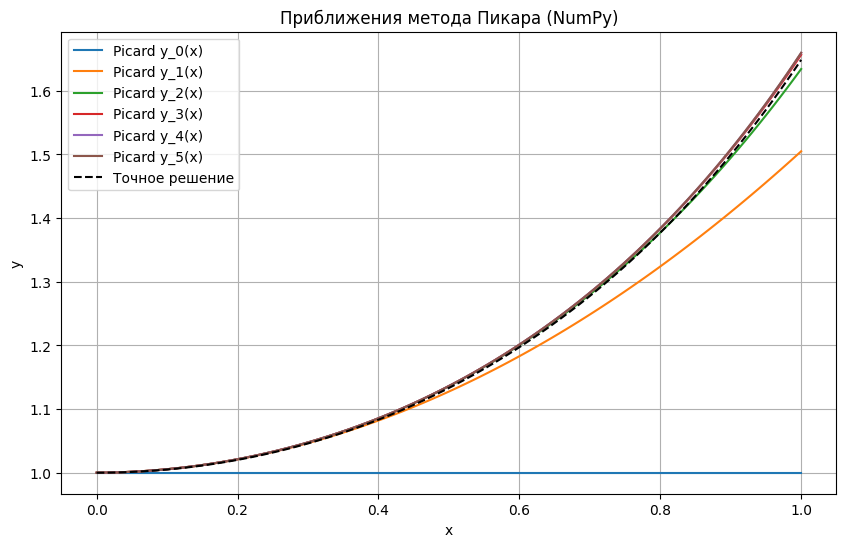

In [10]:
def picard_method(f, x0, y0, n_iter):
    x_values = np.linspace(x0, 1, 100)
    y_approximations = np.zeros((n_iter + 1, len(x_values)))

    # The 0-th approximation is the initial condition y0 for all x
    y_approximations[0, :] = y0

    # Calculate step size for numerical integration
    delta_x = x_values[1] - x_values[0]

    for i in range(1, n_iter + 1):
        y_prev_approx = y_approximations[i - 1, :]
        # Numerical integration step: y_n+1(x) = y0 + integral(f(t, y_n(t)) dt from x0 to x)
        # Approximating integral(f(t, y_n(t)) dt from x0 to x) as cumsum(f(x_vals, y_n(x_vals)) * delta_x)
        y_approximations[i, :] = y0 + np.cumsum(f(x_values, y_prev_approx) * delta_x)

    return x_values, y_approximations

dxdy = lambda x, y: x * y

exact_solution = lambda x: np.exp(x**2 / 2)

x0 = 0
y0 = 1
n_iter = 5

x_values, y_values = picard_method(dxdy, x0, y0, n_iter)

plt.figure(figsize=(10, 6))
for i in range(n_iter + 1):
    plt.plot(x_values, y_values[i, :], label=f'Picard y_{i}(x)')

plt.plot(x_values, exact_solution(x_values), linestyle='--', color='k', label='Точное решение')

plt.title("Приближения метода Пикара (NumPy)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

### Отчет по Упражнению 2 (Метод Пикара с NumPy)
Первая часть Упражнения 2 демонстрирует метод итераций Пикара для решения того же ОДУ, $dy/dx = x*y$ с $y(0) = 1$. Этот метод итеративно строит последовательность функций, которые сходятся к решению. Каждая итерация $y_{n+1}(x)$ вычисляется путем интегрирования $f(t, y_n(t))$ от $x_0$ до $x$ и добавления $y_0$. Графики показывают, как каждая последующая итерация метода Пикара (до $n_{iter} = 5$) постепенно приближается к точному решению $y = e^{x^2/2}$, иллюстрируя его сходимость.

In [ ]:
x = sp.symbols('x')
dydx = sp.Function('dydx')(x)

def pickars(dxdy, x0, y0, n):
  appr = [y0]
  for i in range(n):
    yn = appr[-1]
    yIntegr = y0 + sp.integrate(dydx.subs(y, yn), (x, x0, x))
    appr.append(yIntegr)
  return appr

n = 5
dydx = lambda x,y : x*y
x0, y0 = 0, 1
a, b = 0, 1
print(pickars(dydx, x0, y0, n))

### Отчет по Упражнению 2 (Метод Пикара с SymPy - Ошибка и Исправление)
Вторая часть Упражнения 2 пыталась реализовать метод Пикара с использованием SymPy для символьного интегрирования. Ошибка `AttributeError: 'function' object has no attribute 'subs'` возникла потому, что `dydx` был определен как лямбда-функция Python (`dydx = lambda x,y : x*y`), а не как символьное выражение SymPy. Метод `subs` SymPy используется для подстановки значений в символьные выражения, а не в функции Python.

Ниже представлено исправленное решение, где `dydx` корректно определяется как символьное выражение SymPy, и метод Пикара реализуется с использованием символьного интегрирования.

In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, y = sp.symbols('x, y')
def pickars_sympy(dydx_expr, x0, y0, n_iter):
  appr = [y0]  # y_0(x) = y0
  for i in range(n_iter):
    yn = appr[-1]
    # Integrate dydx_expr with y replaced by yn
    # The integration variable is x
    integral = sp.integrate(dydx_expr.subs(y, yn), (x, x0, x))
    y_new = y0 + integral
    appr.append(y_new)
  return appr

# Define the symbolic ODE
dydx_symbolic = x * y

x0_sym, y0_sym = 0, 1
n_iter_sym = 5

approximations = pickars_sympy(dydx_symbolic, x0_sym, y0_sym, n_iter_sym)

print("Приближения Пикара (SymPy):")
for i, approx in enumerate(approximations):
    print(f"y_{i}(x) = {approx}")

# Evaluate and plot the approximations
# We need to convert sympy expressions to functions for plotting
exact_solution_sym = sp.exp(x**2 / 2)

x_vals = np.linspace(0, 1, 100)
plt.figure(figsize=(10, 6))

for i, approx in enumerate(approximations):
    # Convert sympy expression to a callable function
    y_func = sp.lambdify(x, approx, 'numpy')
    y_plot_vals = y_func(x_vals)

    # Check if y_plot_vals is a scalar (which happens for constant approximations)
    # If it is, convert it to an array of the same shape as x_vals
    if np.isscalar(y_plot_vals):
        y_plot_vals = np.full_like(x_vals, y_plot_vals)

    plt.plot(x_vals, y_plot_vals, label=f'Picard y_{i}(x)')

exact_func = sp.lambdify(x, exact_solution_sym, 'numpy')
plt.plot(x_vals, exact_func(x_vals), 'k--', label='Точное решение')

plt.title("Приближения метода Пикара (SymPy)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

# Отчет по лабораторной работе

## Отчет по Упражнению 1 (Метод Эйлера)
В этом упражнении реализован метод Эйлера с адаптивным контролем шага для решения обыкновенного дифференциального уравнения (ОДУ) $dy/dx = x*y$ с начальным условием $y(0) = 1$. Функция `compY` выполняет один шаг вычисления методом Эйлера, а функция `eulers` итеративно уточняет размер шага ($n_0$), удваивая его до тех пор, пока разница между последовательными приближениями не станет меньше заданного допуска $\varepsilon$. Результаты показывают, что по мере уменьшения $\varepsilon$ (что означает требование более высокой точности), приближение становится ближе к точному решению $y = e^{x^2/2}$. Графики наглядно демонстрируют сходимость метода Эйлера к истинному решению.

## Отчет по Упражнению 2 (Метод Пикара с NumPy)
Первая часть Упражнения 2 демонстрирует метод итераций Пикара для решения того же ОДУ, $dy/dx = x*y$ с $y(0) = 1$. Этот метод итеративно строит последовательность функций, которые сходятся к решению. Каждая итерация $y_{n+1}(x)$ вычисляется путем интегрирования $f(t, y_n(t))$ от $x_0$ до $x$ и добавления $y_0$. Графики показывают, как каждая последующая итерация метода Пикара (до $n_{iter} = 5$) постепенно приближается к точному решению $y = e^{x^2/2}$, иллюстрируя его сходимость.

## Отчет по Упражнению 2 (Метод Пикара с SymPy - Ошибка и Исправление)
Вторая часть Упражнения 2 пыталась реализовать метод Пикара с использованием SymPy для символьного интегрирования. Ошибка `AttributeError: 'function' object has no attribute 'subs'` возникла потому, что `dydx` был определен как лямбда-функция Python (`dydx = lambda x,y : x*y`), а не как символьное выражение SymPy. Метод `subs` SymPy используется для подстановки значений в символьные выражения, а не в функции Python.

Ниже представлено исправленное решение, где `dydx` корректно определяется как символьное выражение SymPy, и метод Пикара реализуется с использованием символьного интегрирования.